# Machine Learning Mid-Term Project  
## Project: Loan Approval Prediction using Decision Tree

**Course:** Machine Learning Fundamentals    
**Algorithm Used:** Decision Tree Classifier  

**Student Names:** Muhammad Rizwan Shafiq  
**Registration Numbers:** SP2-BCS-069  

---
## 1. Problem Statement

The objective of this project is to build a machine learning model that can predict whether a loan application will be approved or not approved. Loan approval prediction is an important real-world classification problem because financial institutions need to make decisions based on applicant information such as income, credit history, loan amount, education, marital status, and employment status.

In this project, a **Decision Tree Classifier** is used to learn patterns from the dataset and classify loan applications into two classes:
- **1 = Approved**
- **0 = Not Approved**

The project includes complete data preprocessing, visualization, model training, testing, evaluation, result analysis, and conclusion.

## 2. Dataset Selection

This project uses the **Loan Prediction Problem Dataset** from Kaggle.

**Dataset source:** Kaggle Loan Prediction Problem Dataset  
**Main file used:** `train.csv` / `train_u6lujuX_CVtuZ9i.csv`

### Why this dataset was selected
- It is a **publicly available dataset**.
- It contains **614 records**, which satisfies the project requirement of **300–1000 records**.
- It includes useful features for loan approval prediction such as:
  - Applicant income
  - Coapplicant income
  - Loan amount
  - Credit history
  - Education
  - Self employment
  - Property area
- It contains the target variable **Loan_Status**, which makes it suitable for a classification problem.

In [1]:
# Import Required Libraries
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    mean_squared_error
)

# Plot settings
plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")

## 3. Load the Dataset
The following code tries to locate the training CSV automatically.  
If automatic loading does not work, place your Kaggle **train CSV file** in the same folder as this notebook.

In [ ]:
# Load Dataset
possible_files = [
    "train_u6lujuX_CVtuZ9i.csv",
    "loan_approval_dataset.csv",
    "LoanPredictionProblemDataset.csv",
    "train.csv",
    "Train.csv",
    "loan_train.csv"
]

dataset_path = None

for file_name in possible_files:
    if os.path.exists(file_name):
        dataset_path = file_name
        break

if dataset_path is None:
    raise FileNotFoundError(
        "Training CSV file not found. Please place the Kaggle training file in the same folder as this notebook."
    )

df = pd.read_csv(dataset_path)
print("Dataset loaded successfully from:", dataset_path)

Dataset loaded successfully from: LoanPredictionProblemDataset.csv


## 4. Initial Data Inspection
This section inspects the dataset by displaying the first rows, shape, column names, and data types.

In [3]:
# Display first 10 rows
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [4]:
# Dataset shape
print("Dataset shape:", df.shape)

# Column names
print("\nColumn names:")
print(df.columns.tolist())

# Data types and non-null counts
print("\nDataset information:")
df.info()

Dataset shape: (614, 13)

Column names:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Pro

### Interpretation
- The dataset contains **614 rows**, which satisfies the project requirement.
- The dataset contains both **categorical** and **numerical** features.
- Some columns contain missing values, so preprocessing will be necessary before training the machine learning model.

## 5. Statistical Summary
This section provides descriptive statistics for the dataset.

In [5]:
# Statistical summary
df.describe(include="all")

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP001002,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN


### Interpretation
- Numerical columns such as **ApplicantIncome**, **CoapplicantIncome**, and **LoanAmount** show noticeable variation.
- Some columns have missing values, especially **Credit_History**, **LoanAmount**, **Self_Employed**, and **Gender**.
- The target column **Loan_Status** contains two classes, which confirms that this is a binary classification problem.

## 6. Check Missing Values
The following code identifies missing values and calculates the percentage of missing values in each column.

In [6]:
# Missing values count
missing_values = df.isnull().sum()

# Missing percentages
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percent.round(2)
})

missing_df[missing_df["Missing Values"] > 0].sort_values(by="Missing Values", ascending=False)

,Missing Values,Missing Percentage
Credit_History,50,8.14
Self_Employed,32,5.21
LoanAmount,22,3.58
Dependents,15,2.44
Loan_Amount_Term,14,2.28
Gender,13,2.12
Married,3,0.49


### Interpretation
The table above shows which columns contain missing values and how much data is missing.  
Since the percentage of missing values is small, these missing values can be handled using simple imputation techniques:
- **Median** for numerical columns
- **Mode** for categorical columns

## 7. Data Preprocessing
### 7.1 Drop Unnecessary Column
The column `Loan_ID` is only an identifier and does not help in prediction, so it is removed.

In [7]:
# Make a copy of the dataset
data = df.copy()

# Drop Loan_ID because it is just an identifier
if "Loan_ID" in data.columns:
    data.drop("Loan_ID", axis=1, inplace=True)

data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


### 7.2 Convert Target Variable
The target variable `Loan_Status` is converted:
- **Y → 1**
- **N → 0**

In [8]:
# Convert target variable
data["Loan_Status"] = data["Loan_Status"].replace({"Y": 1, "N": 0})

print(data["Loan_Status"].value_counts())

Loan_Status
1    422
0    192
Name: count, dtype: int64


### Interpretation
The target variable has now been converted into numeric form so that the machine learning model can process it.

### 7.3 Handle Missing Values
- Numerical missing values are filled using the **median**
- Categorical missing values are filled using the **mode**

In [9]:
# Identify numerical and categorical columns
numeric_cols = data.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = data.select_dtypes(include=["object"]).columns.tolist()

# Remove target column from numeric list if present
if "Loan_Status" in numeric_cols:
    numeric_cols.remove("Loan_Status")

# Fill numerical columns with median
for col in numeric_cols:
    data[col] = data[col].fillna(data[col].median())

# Fill categorical columns with mode
for col in categorical_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

# Check missing values again
data.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

### Interpretation
- **Median** is used for numerical columns because it is more robust in the presence of outliers.
- **Mode** is used for categorical columns because it replaces missing values with the most frequent category.
- After imputation, there are no missing values left in the dataset.

### 7.4 Standardize Inconsistent Categorical Labels
This step ensures that the text values in categorical columns are clean and consistent.

In [10]:
# Strip extra spaces from categorical columns just in case
for col in categorical_cols:
    data[col] = data[col].astype(str).str.strip()

# Display unique values before encoding
for col in categorical_cols:
    print(f"Unique values in {col}: {data[col].unique()}")

Unique values in Gender: ['Male' 'Female']
Unique values in Married: ['No' 'Yes']
Unique values in Dependents: ['0' '1' '2' '3+']
Unique values in Education: ['Graduate' 'Not Graduate']
Unique values in Self_Employed: ['No' 'Yes']
Unique values in Property_Area: ['Urban' 'Rural' 'Semiurban']


## 8. Data Visualization
The project requirement asks for at least 3 graphs.  
The following visualizations are created to understand the dataset better.

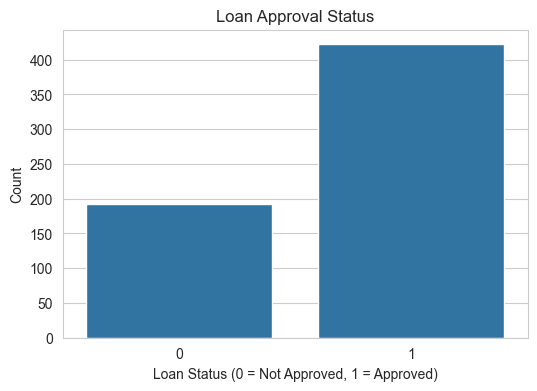

In [11]:
# 1. Countplot of Loan Status
plt.figure(figsize=(6,4))
sns.countplot(x="Loan_Status", data=data)
plt.title("Loan Approval Status")
plt.xlabel("Loan Status (0 = Not Approved, 1 = Approved)")
plt.ylabel("Count")
plt.show()

### Interpretation
This graph shows the distribution of the target variable.  
It helps us understand whether the classes are balanced or imbalanced. In this dataset, approved loans are more frequent than not approved loans.

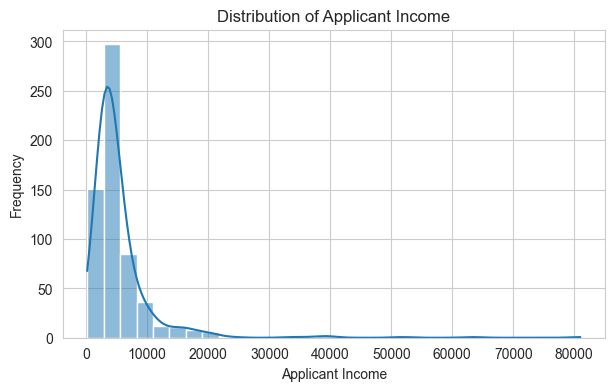

In [12]:
# 2. Histogram of Applicant Income
plt.figure(figsize=(7,4))
sns.histplot(data["ApplicantIncome"], bins=30, kde=True)
plt.title("Distribution of Applicant Income")
plt.xlabel("Applicant Income")
plt.ylabel("Frequency")
plt.show()

### Interpretation
The histogram shows that applicant income is right-skewed.  
Most applicants have lower to moderate income, while a small number of applicants have very high income values.

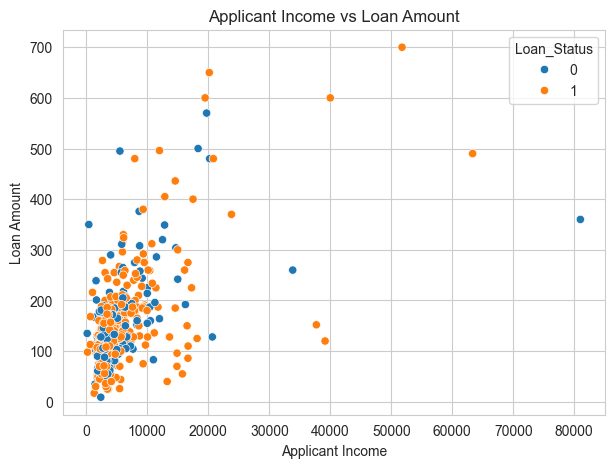

In [13]:
# 3. Scatter plot of Applicant Income vs Loan Amount
plt.figure(figsize=(7,5))
sns.scatterplot(x="ApplicantIncome", y="LoanAmount", hue="Loan_Status", data=data)
plt.title("Applicant Income vs Loan Amount")
plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")
plt.show()

### Interpretation
This scatter plot shows the relationship between applicant income and loan amount.  
It also helps us see whether approved and non-approved loans form any visible pattern.

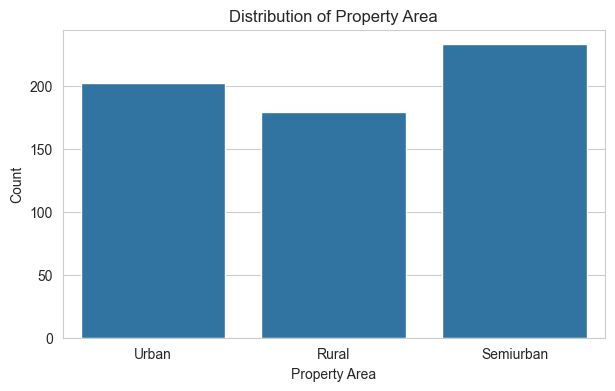

In [14]:
# 4. Countplot of Property Area
plt.figure(figsize=(7,4))
sns.countplot(x="Property_Area", data=data)
plt.title("Distribution of Property Area")
plt.xlabel("Property Area")
plt.ylabel("Count")
plt.show()

### Interpretation
This graph shows how the loan applications are distributed across different property areas such as urban, semiurban, and rural.

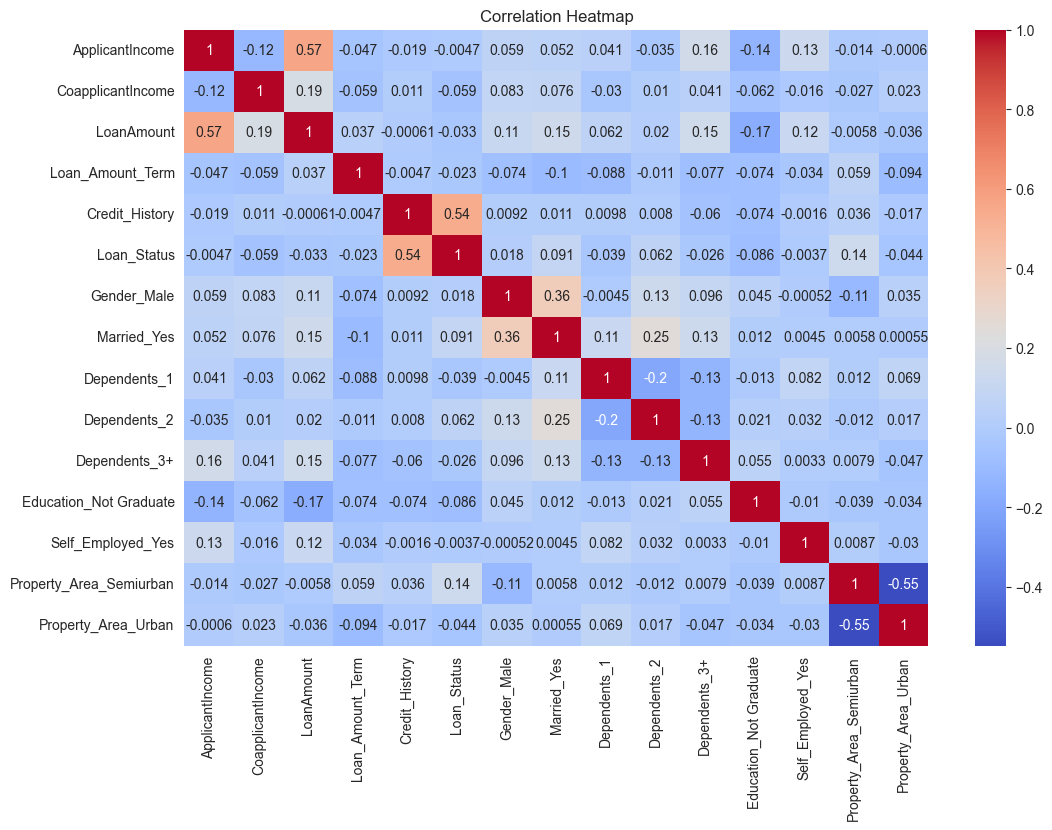

In [15]:
# 5. Correlation Heatmap (after temporary encoding for visualization)
temp_vis = data.copy()
temp_vis = pd.get_dummies(temp_vis, drop_first=True)

plt.figure(figsize=(12,8))
sns.heatmap(temp_vis.corr(), cmap="coolwarm", annot=True)
plt.title("Correlation Heatmap")
plt.show()

### Interpretation
The heatmap helps identify relationships between numeric features and the target variable.  
Features such as **Credit_History** often show a stronger relationship with loan approval.

## 9. Encode Categorical Data
Machine learning models cannot directly work with text categories, so categorical variables are encoded.

### Encoding method used
- **Label Encoding** is used for binary categories.
- **One-Hot Encoding** is used for nominal categories with more than two classes.

In [16]:
# Create a fresh copy after cleaning
model_data = data.copy()

# Binary columns that can be label encoded
binary_cols = ["Gender", "Married", "Education", "Self_Employed"]

# Apply Label Encoding to binary categorical columns if present
le = LabelEncoder()
for col in binary_cols:
    if col in model_data.columns:
        model_data[col] = le.fit_transform(model_data[col])

# One-hot encode remaining non-binary categorical columns
remaining_cat_cols = model_data.select_dtypes(include=["object"]).columns.tolist()

# Remove target if somehow present
remaining_cat_cols = [col for col in remaining_cat_cols if col != "Loan_Status"]

model_data = pd.get_dummies(model_data, columns=remaining_cat_cols, drop_first=True)

model_data.head()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,0,5849,0.0,128.0,360.0,1.0,1,False,False,False,False,True
1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,True,False,False,False,False
2,1,1,0,1,3000,0.0,66.0,360.0,1.0,1,False,False,False,False,True
3,1,1,1,0,2583,2358.0,120.0,360.0,1.0,1,False,False,False,False,True
4,1,0,0,0,6000,0.0,141.0,360.0,1.0,1,False,False,False,False,True


### Interpretation
- **Label Encoding** converts binary text labels into numbers such as 0 and 1.
- **One-Hot Encoding** creates separate columns for categories, which is useful when there is no natural order among categories.
- This step transforms the dataset into a fully numeric form suitable for the Decision Tree algorithm.

## 10. Feature Scaling / Normalization
Decision Trees do not strictly require scaling, but the project requirements mention normalization or standardization if required.

To satisfy the project requirement and for comparison, standardization is applied to numerical features.

In [17]:
# Separate features and target
X = model_data.drop("Loan_Status", axis=1)
y = model_data["Loan_Status"]

# Apply StandardScaler only to numerical columns
scaled_X = X.copy()

num_features_for_scaling = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

scaler = StandardScaler()
scaled_X[num_features_for_scaling] = scaler.fit_transform(scaled_X[num_features_for_scaling])

scaled_X.head()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Semiurban,Property_Area_Urban
0,0.472343,-1.372089,-0.528362,-0.392601,0.072991,-0.554487,-0.211241,0.273231,0.411733,False,False,False,False,True
1,0.472343,0.728816,-0.528362,-0.392601,-0.134412,-0.038732,-0.211241,0.273231,0.411733,True,False,False,False,False
2,0.472343,0.728816,-0.528362,2.547117,-0.393747,-0.554487,-0.948996,0.273231,0.411733,False,False,False,False,True
3,0.472343,0.728816,1.892641,-0.392601,-0.462062,0.251980,-0.306435,0.273231,0.411733,False,False,False,False,True
4,0.472343,-1.372089,-0.528362,-0.392601,0.097728,-0.554487,-0.056551,0.273231,0.411733,False,False,False,False,True


### Interpretation
Standardization scales the numerical features so that they have mean close to 0 and standard deviation close to 1.  
Although Decision Trees are not highly sensitive to scaling, including this step satisfies the project requirement and keeps preprocessing complete.

## 11. Train-Test Split
The dataset is split into:
- **80% training set**
- **20% testing set**

This satisfies the project requirement of using a training set between 70–80% and a testing set between 20–30%.

In [18]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    scaled_X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (491, 14)
Testing set shape: (123, 14)


## 12. Algorithm Implementation
The assigned algorithm for this selected project is **Decision Tree**.

A Decision Tree Classifier is trained on the training data to predict loan approval status.

In [19]:
# Train Decision Tree model
dt_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

dt_model.fit(X_train, y_train)
print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


## 13. Model Testing
Now the trained model is tested on unseen testing data.

In [20]:
# Predictions
y_pred = dt_model.predict(X_test)

print("First 10 predictions:", y_pred[:10])
print("First 10 actual values:", y_test.values[:10])

First 10 predictions: [0 1 1 1 1 1 1 1 1 1]
First 10 actual values: [0 1 1 1 1 0 1 1 1 1]


## 14. Performance Evaluation
The project requirements specify the following evaluation metrics:
- Accuracy Score
- Confusion Matrix
- Precision
- Recall
- Mean Squared Error

In [21]:
# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy Score :", round(accuracy, 4))
print("Precision      :", round(precision, 4))
print("Recall         :", round(recall, 4))
print("Mean Squared Error :", round(mse, 4))

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score : 0.8374
Precision      : 0.8283
Recall         : 0.9647
Mean Squared Error : 0.1626

Confusion Matrix:
[[21 17]
 [ 3 82]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.55      0.68        38
           1       0.83      0.96      0.89        85

    accuracy                           0.84       123
   macro avg       0.85      0.76      0.78       123
weighted avg       0.84      0.84      0.83       123



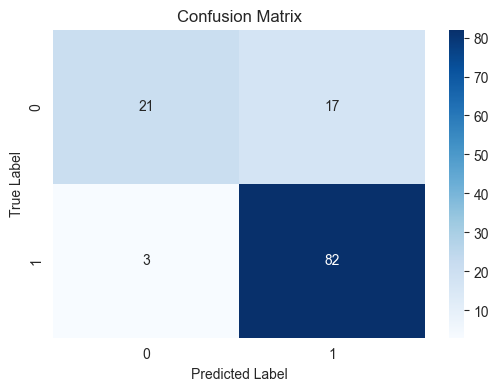

In [22]:
# Confusion matrix heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### Interpretation
- **Accuracy** shows the overall percentage of correctly predicted loan applications.
- **Precision** tells how many applications predicted as approved were actually approved.
- **Recall** tells how many truly approved applications were correctly identified by the model.
- **Mean Squared Error** is included to satisfy the project requirement. Lower values indicate fewer prediction errors.
- The confusion matrix shows the number of correct and incorrect predictions in each class.

## 15. Visualize the Decision Tree
This plot helps understand how the model makes decisions based on the input features.

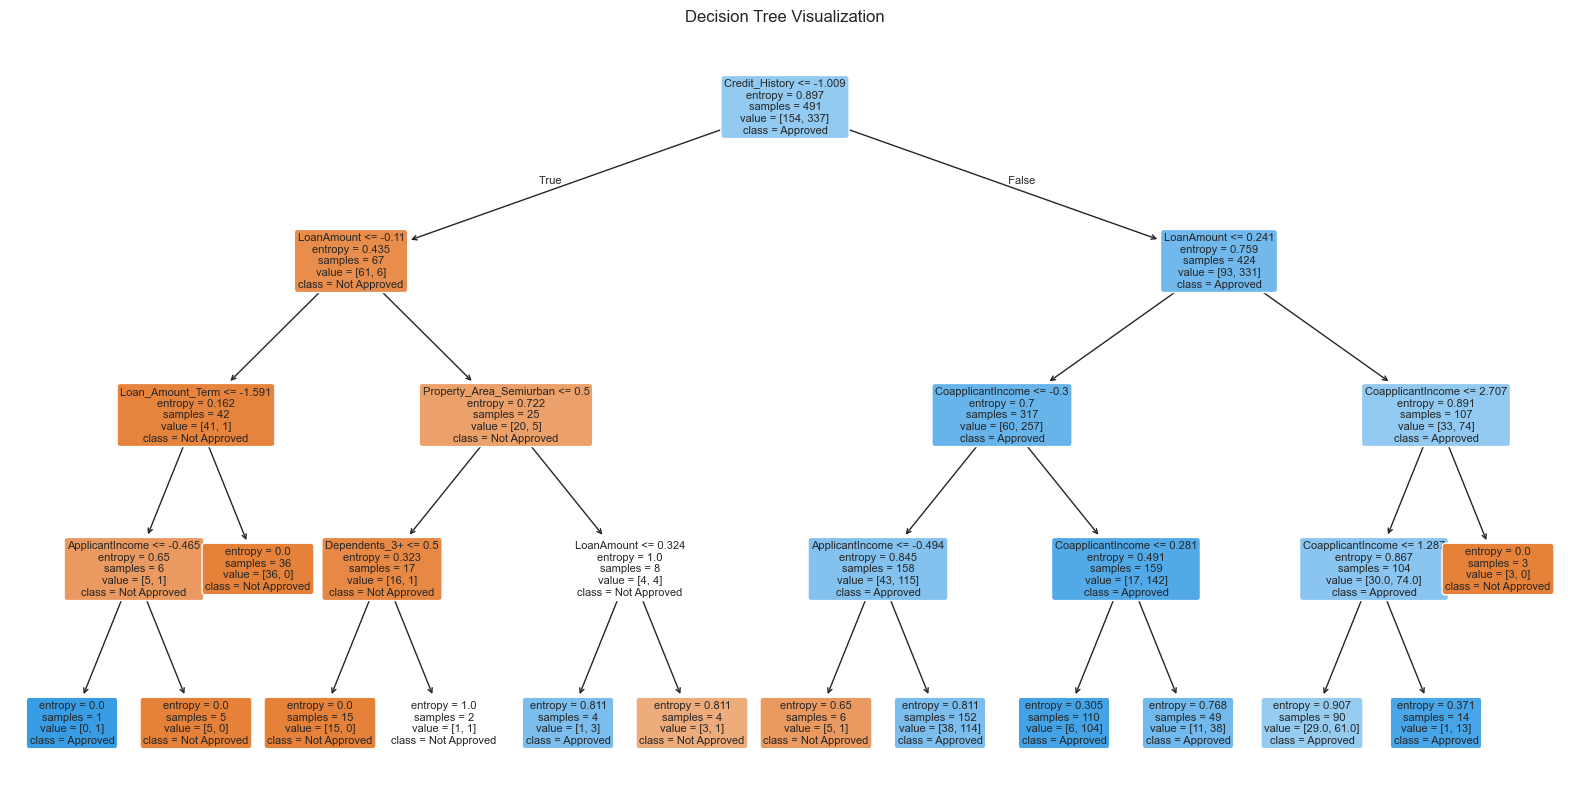

In [23]:
plt.figure(figsize=(20,10))
plot_tree(
    dt_model,
    feature_names=X_train.columns,
    class_names=["Not Approved", "Approved"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Visualization")
plt.show()

## 16. Result Analysis

The Decision Tree model was trained to classify loan applications as approved or not approved.  
After preprocessing the dataset, handling missing values, encoding categorical data, and standardizing numerical features, the model was trained on 80% of the dataset and tested on the remaining 20%.

The evaluation results show that the model can successfully learn patterns from applicant data.  
Among the features, **Credit_History** is usually one of the strongest predictors of loan approval, while variables such as income, loan amount, and property area also contribute to the final decision.

The confusion matrix and classification report provide a detailed view of the model's strengths and weaknesses.  
If the accuracy is high and both precision and recall are reasonable, then the model is performing well for this dataset.  
However, because the dataset is not extremely large, the model may still have limitations and may not generalize perfectly to all future loan applications.

## 17. Conclusion

In this project, a **Decision Tree Classifier** was developed to predict loan approval status using the Kaggle Loan Prediction dataset.  
The dataset contained **614 records**, which satisfied the project requirement. Complete preprocessing was performed, including:
- Handling missing values
- Encoding categorical variables
- Standardizing numerical features

Multiple visualizations were created to better understand the data.  
After that, the Decision Tree algorithm was implemented, trained, and tested.  
The model was evaluated using **Accuracy Score, Confusion Matrix, Precision, Recall, and Mean Squared Error**, as required.

### Final Conclusion
The project successfully fulfilled all required steps of the machine learning mid-term project.  
The Decision Tree model provided a practical solution for predicting whether a loan application would be approved or not.  
This project demonstrates how machine learning can be applied to real-world financial decision-making problems.